In [1]:
import numpy as np
import tensorflow as tf
import keras
import csv
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import sys
sys.path.append("..")
import minimise

# Enable or disable Tensor Float 32 Execution
tf.config.experimental.enable_tensor_float_32_execution(False)

2025-03-23 12:17:51.066271: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-23 12:17:51.071900: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-23 12:17:51.126100: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-23 12:17:51.183324: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742732271.226824   28069 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742732271.24

In [2]:
def write_profile(filename, centers, densities):
    """
    Write the density profiles to a file.

    Parameters:
    - filename (str): Output file name.
    - centers (np.ndarray): Bin centers.
    - densities (np.ndarray): Density values.
    """
    with open(filename, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile, delimiter=' ')
        writer.writerow(["xbins", "rho"])
        for center, density in zip(centers, densities):
            writer.writerow([f"{center:.4f}", f"{density:.20f}"])


def LJ_wall(position, low, high, epsilon=2, sigma=1):
    r_low = position - low
    r_high = high - position
    
    energy_low = 4 * epsilon * ((sigma / r_low)**12 - (sigma / r_low)**6)
    energy_high = 4 * epsilon * ((sigma / r_high)**12 - (sigma / r_high)**6)
    
    return np.where((position >= high) | (position <= low), 1e30, energy_low + energy_high)


def get_slit_profile_lr(model_path, output_file, temp, mu):

    """
    Determine the self-consistent density profiles with neural DFT for a confined fluid.

    Parameters:
    - model_path (str): Path to the Keras model.
    - data_path (str): Path to the simulation data.
    - results_path (str): Path to save the results.
    - temp (float): Temperature
    - mu (float): Chemical potential in units of kbT
    """

    model = keras.models.load_model(model_path)

    zbins = np.linspace(0.005, 9.995, num=2000)
    Vext = LJ_wall(zbins, 0.5, 9.5)
    T = np.linspace(temp, temp, num=2000)

    zs, rho = minimise.minimise_LR(model, zbins, -Vext, T, rc=2.5, mu=mu,
                                                        initial_guess=0.5, input_bins=1201, plot=False, 
                                                        tolerance=1e-6, maxiter=100000)
    
    if zs is not None:
        write_profile(output_file, zs, rho)



def get_slit_profile_sr(model_path, output_file, temp, mu):

    """
    Determine the self-consistent density profiles with neural DFT for a confined fluid.

    Parameters:
    - model_path (str): Path to the Keras model.
    - data_path (str): Path to the simulation data.
    - results_path (str): Path to save the results.
    - temp (float): Temperature
    - mu (float): Chemical potential in units of kbT
    """

    model = keras.models.load_model(model_path)

    zbins = np.linspace(0.005, 9.995, num=2000)
    Vext = LJ_wall(zbins, 0.5, 9.5)
    T = np.linspace(temp, temp, num=2000)
    muloc = -Vext + mu

    zs, rho = minimise.minimise_SR(model, zbins, muloc, T,
                                    initial_guess=0.5, input_bins=1201, plot=False, 
                                    tolerance=1e-6, maxiter=100000)
    
    if zs is not None:
        write_profile(output_file, zs, rho)

## WCA

#### Get Density Profiles

In [4]:
mu_range = [-5, -2, -1, 0, 3]
model_path = "../../models/WCA.keras"
# T = 1.5 to compare with simulation

In [3]:
for betamu in mu_range:
    output_file = "../data/sr_pred_slit{}_T{}.out".format(betamu, 1.5)
    get_slit_profile_sr(model_path, output_file, temp=1.5, mu=betamu)

2025-03-23 12:14:08.717960: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
I0000 00:00:1742732048.922789   27914 service.cc:148] XLA service 0x7a00f401b290 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1742732048.922821   27914 service.cc:156]   StreamExecutor device (0): Host, Default Version
I0000 00:00:1742732048.987702   27914 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Converged after 1753 iterations (delta = 9.989952247241307e-07)
Converged after 1935 iterations (delta = 9.838804141404367e-07)
Converged after 2006 iterations (delta = 9.942408079055554e-07)
Converged after 2044 iterations (delta = 1.2117774974562678e-06)
Converged after 2279 iterations (delta = 2.24211593691237e-06)


#### Load Data and Plot

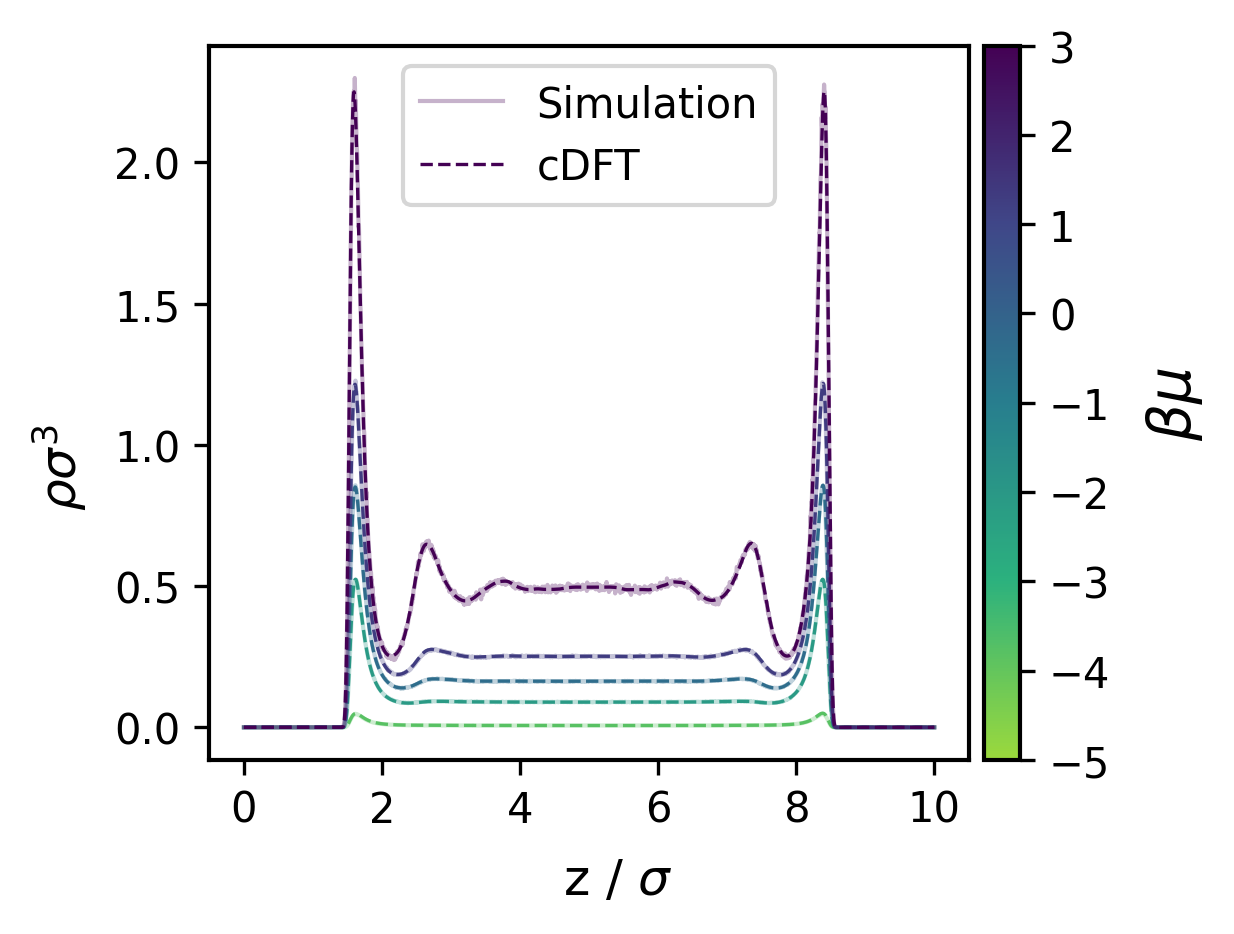

In [6]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(4, 3), layout="compressed", sharex=True, sharey=True)

orig_cmap = plt.cm.viridis_r
norm = mcolors.Normalize(vmin=min(mu_range), vmax=max(mu_range))
colors = orig_cmap(np.linspace(0.15, 1, len(mu_range)))
cmap = mcolors.LinearSegmentedColormap.from_list("mycmap", colors)
plot_colour = cmap(np.linspace(0.15, 1, len(mu_range)))

for i in range(len(mu_range)):

    data = "../data/simulation/density_profiles/profiles_wca_slit{}_T{:.1f}.out".format(mu_range[i], 1.5)
    pred = "../data/results/density_profiles/sr_pred_slit{}_T{:.1f}.out".format(mu_range[i], 1.5)

    sim = pd.read_csv(data, sep=" ")
    nn = pd.read_csv(pred, sep = " ")

    xbins = sim["xbins"].to_numpy()

    ax.plot(xbins, sim["rho"].to_numpy(), label="Simulation" if i == len(mu_range)-1 else "", lw=1, color=plot_colour[i], alpha=0.3)
    ax.plot(xbins, nn["rho"].to_numpy(), label="cDFT" if i == len(mu_range)-1 else "", lw=0.8, color=plot_colour[i], linestyle="dashed")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label('$ \\beta \\mu $', labelpad=8)
cbar.set_ticks(ticks=mu_range)

fig.supxlabel("z / $\\sigma$")
fig.supylabel("$\\rho \\sigma^3$")

ax.legend()

#plt.savefig("../slit_profiles_wca.png", bbox_inches="tight",dpi=600, pad_inches=0.01)
plt.show()

#### LJ

In [7]:
mu_range = [-5, -4, -3, -2, -1, 0]
T_range = [1.5, 2.0]
model_path = "../../models/WCA.keras"

#### Get Density Profiles

In [9]:
for betamu in mu_range:
    for T in T_range:
        output_file = "../data/lr_pred_slit{}_T{}.out".format(betamu, T)
        get_slit_profile_lr(model_path, output_file, temp=T, mu=betamu)

2025-03-23 12:19:32.642753: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
I0000 00:00:1742732372.803954   28167 service.cc:148] XLA service 0x72778001b290 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1742732372.804111   28167 service.cc:156]   StreamExecutor device (0): Host, Default Version
I0000 00:00:1742732372.853496   28167 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Converged after 3249 iterations (delta = 9.841168085861218e-07)
Converged after 3223 iterations (delta = 9.97000978497642e-07)
Converged after 3501 iterations (delta = 9.734216997459022e-07)
Converged after 3381 iterations (delta = 9.769285502780889e-07)
Converged after 3585 iterations (delta = 9.671699306990078e-07)
Converged after 3496 iterations (delta = 9.916083753558347e-07)
Converged after 3541 iterations (delta = 1.1113061686440773e-06)
Converged after 3502 iterations (delta = 9.780101591916335e-07)
Converged after 3567 iterations (delta = 1.7037987311008251e-06)
Converged after 3519 iterations (delta = 1.1915565631959169e-06)
Converged after 4258 iterations (delta = 2.4139916967591546e-06)
Converged after 3553 iterations (delta = 1.9805586597421154e-06)


#### Load Data and Plot

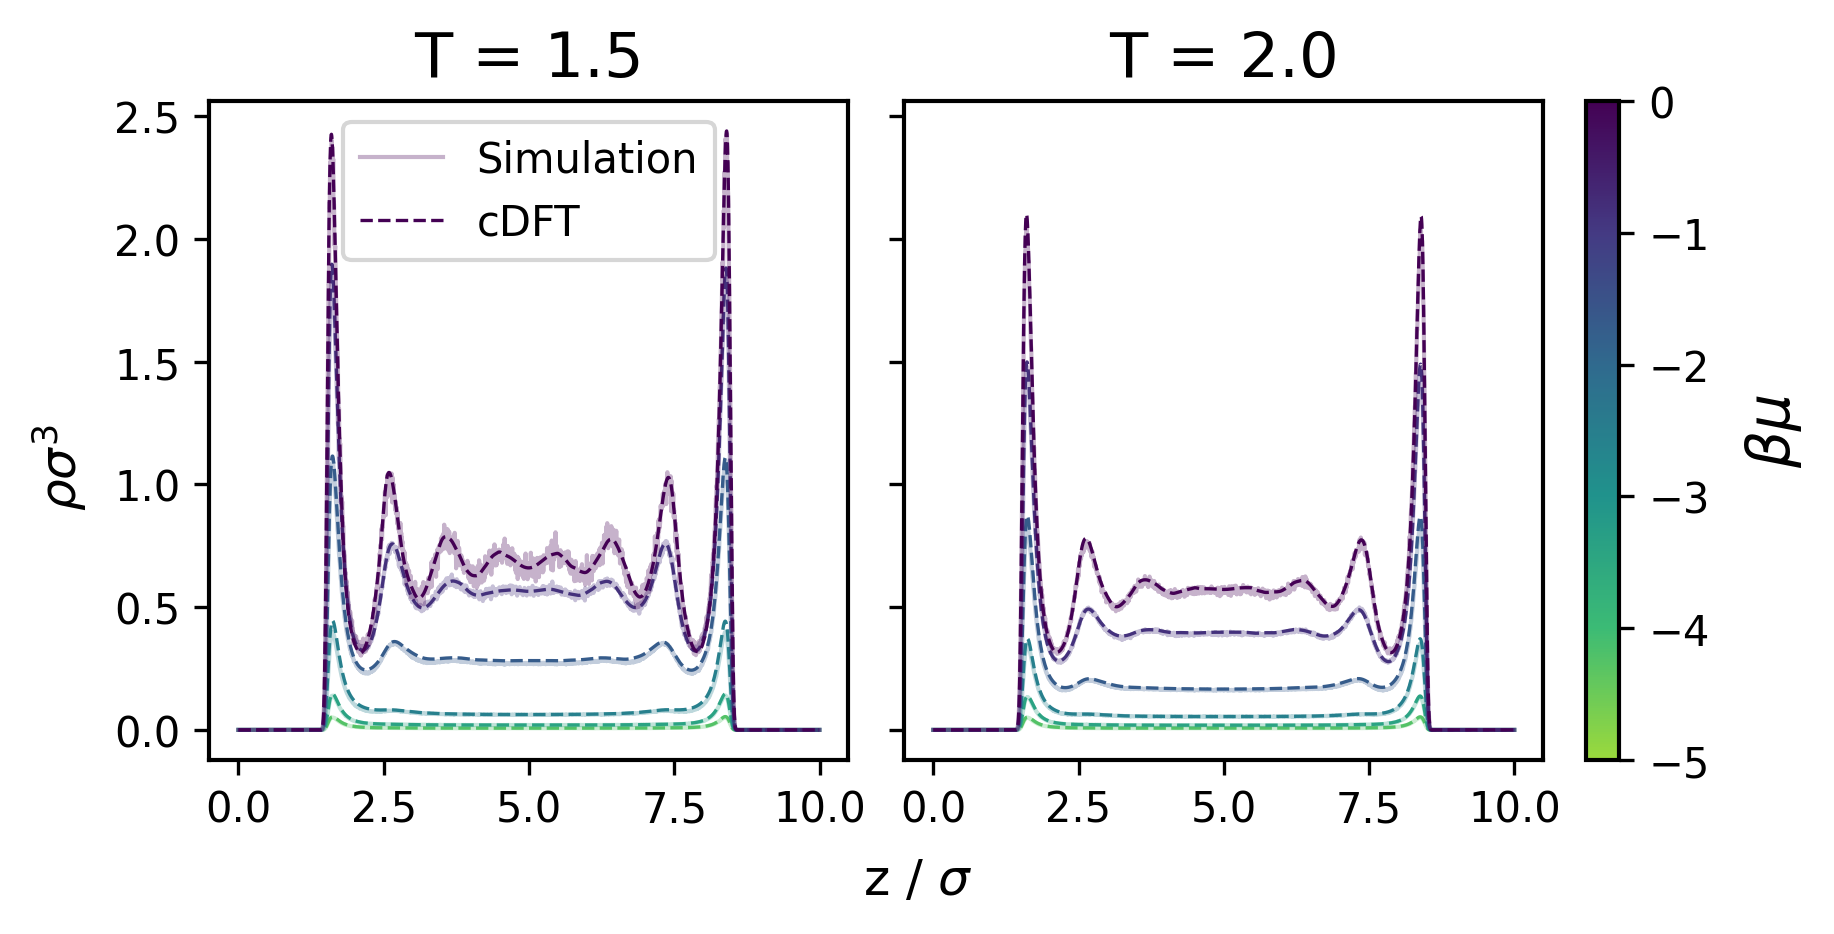

In [11]:
fig, ax = plt.subplots(ncols=len(T_range), nrows=1, figsize=(6, 3), layout="compressed", sharex=True, sharey=True)

orig_cmap = plt.cm.viridis_r
norm = mcolors.Normalize(vmin=min(mu_range), vmax=max(mu_range))
colors = orig_cmap(np.linspace(0.15, 1, len(mu_range)))
cmap = mcolors.LinearSegmentedColormap.from_list("mycmap", colors)
plot_colour = cmap(np.linspace(0.15, 1, len(mu_range)))

for i in range(len(mu_range)):
    for j in range(len(T_range)):

        data = "../data/simulation/density_profiles/profiles_lj_slit{}_T{:.1f}.out".format(mu_range[i], T_range[j])
        pred = "../data/results/density_profiles/lr_pred_slit{}_T{:.1f}.out".format(mu_range[i], T_range[j])

        sim = pd.read_csv(data, sep=" ")
        nn = pd.read_csv(pred, sep = " ")

        xbins = sim["xbins"].to_numpy()

        ax[j].plot(xbins, sim["rho"].to_numpy(), label="Simulation" if i == len(mu_range)-1 else "", lw=1, color=plot_colour[i], alpha=0.3)
        ax[j].plot(xbins, nn["rho"].to_numpy(), label="cDFT" if i == len(mu_range)-1 else "", lw=0.8, color=plot_colour[i], linestyle="dashed")

        ax[j].set_title("T = {:.1f}".format(T_range[j]))

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label('$ \\beta \\mu $', labelpad=8)

fig.supxlabel("z / $\\sigma$")
fig.supylabel("$\\rho \\sigma^3$")

ax[0].legend()

#plt.savefig("../slit_profiles_lj.png", bbox_inches="tight",dpi=600, pad_inches=0.01)
plt.show()